In [2]:
print('Radha!')

Radha!


In [3]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from dotenv import load_dotenv

In [4]:
# create states
class State(TypedDict):

    user_message : str
    intent : str 
    response : str

In [5]:
def classify_intent(state: State)-> State:

    message = state['user_message'].lower()

    if 'order' in message:
        return {
            'intent':'order'
            }
    
    elif 'password' in message:
        return {
            'intent':'password'
            }

    else:
        return {
            'intent':'greeting'
            }


In [6]:
def order_intent(state: State)-> State:
    return {
        'response': 'Your order will be delivered soon...'
    }

In [7]:
def password_intent(state: State)-> State:
    return{
        'response': 'Our team will contact you soon...'
    }

In [8]:
def greeting_intent(state: State)-> State:
    return{
        'response': 'How can i help you!'
    }

In [9]:
def route_intent(state: State)-> str:
    return state['intent']

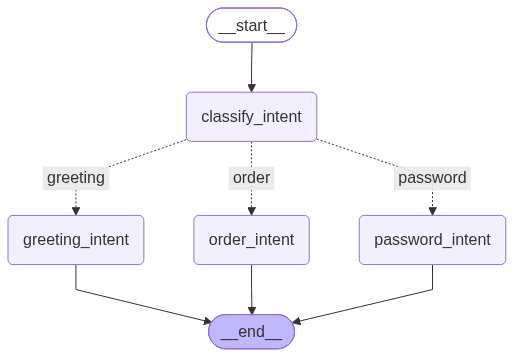

In [10]:
# create node 
graph = StateGraph(State)

graph.add_node('classify_intent', classify_intent)
graph.add_node('order_intent', order_intent)
graph.add_node('password_intent', password_intent)
graph.add_node('greeting_intent', greeting_intent)

# create edges
graph.add_edge(START, 'classify_intent')
graph.add_conditional_edges(
    "classify_intent",
    route_intent,
    {
        "order": "order_intent",
        "password": "password_intent",
        "greeting": "greeting_intent",
    },
)
graph.add_edge("order_intent", END)
graph.add_edge("password_intent", END)
graph.add_edge("greeting_intent", END)

graph.compile()


In [11]:
workflow = graph.compile()
intial_state = {
    'user_message': 'I forgot my password'
}

workflow.invoke(intial_state)

{'user_message': 'I forgot my password',
 'intent': 'password',
 'response': 'Our team will contact you soon...'}